## Analysis of essential gene databases, including the Keio collection, the DEG database, and the study by Lastiri et al. (2020).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from itertools import combinations

In [2]:
##load data.
base_deg = pd.read_csv('/home/notebooks/Notebooks/LIZ/Essential_genes/DEG_synonym.csv')
base_pec = pd.read_csv('/home/notebooks/Notebooks/LIZ/Essential_genes/genes_pec_synon.csv')
keio = pd.read_csv('/home/notebooks/Notebooks/LIZ/Essential_genes/genes_keio276_synon.csv')
genes_nofit = pd.read_csv('/home/notebooks/Notebooks/LIZ/COG/genes_nofit903.csv')
snofit = set(genes_nofit.genes)

In [3]:
set_pec =set(base_pec.GenesReg12)
print('PEC DB =', len(set_pec))
set_deg = set(base_deg.Genes_R12)
print('DEG DB =', len(set_deg))
gkeio = keio.GenesReg12
gkeio2 =set(gkeio)
print('Genes Keio =', len(gkeio))

PEC DB = 304
DEG DB = 296
Genes Keio = 276


In [4]:
MS_GustavoL = pd.read_excel('/home/notebooks/Notebooks/LIZ/Essential_genes/41589_2020_593_MOESM2_ESM.xlsx', sheet_name='Table 1', skiprows=[0, 1])
core_essen = MS_GustavoL[MS_GustavoL['Core Essential'] == 'Core Essential']
core_essen.columns = [['bnum','genes','essen','evid']]
print(len(core_essen))
c_essen = core_essen["genes"]
c_essen
#c_essen.to_csv('/home/notebooks/Notebooks/LIZ/Essential_genes/genes_GL_core521.csv', index=False)
genes_GL = MS_GustavoL.iloc[:,[1]]
genes_GL.columns= ["genes"]
#genes_GL.to_csv('/home/notebooks/Notebooks/LIZ/Essential_genes/genes_GL654_allessen.csv', index=False)

521


In [5]:
print('Genes GL todos=',len(MS_GustavoL))
MS_GustavoL.columns = [['bnum','gene','essen','evid']]
c_essen = MS_GustavoL["gene"]
core_series = c_essen['gene'].squeeze()

Genes GL todos= 654


## Separate the non-fitness genes into essential/non-effect across all conditions.

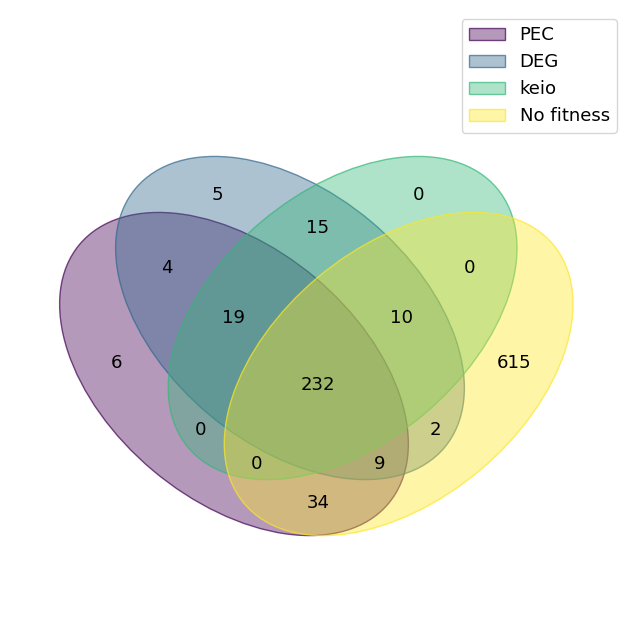

In [13]:
#Include those without fitness data.
import matplotlib.pyplot as plt
from venn import *

datas = {
    "PEC": set_pec,
    "DEG": set_deg,
    "keio" : gkeio2,
    "No fitness" : snofit,
}

venn(datas)
plt.savefig('venn_gnofitness_allconds.svg', format='svg')

/apps/bioconda/envs/general/lib/python3.11/site-packages/venn/_backwards_compatibility.py:15: UserWarning: `get_labels()` is retained for backwards compatibility; use `generate_petal_labels()` or the higher level `venn()` instead
  warn((
/apps/bioconda/envs/general/lib/python3.11/site-packages/venn/_backwards_compatibility.py:30: UserWarning: `venn4()` is retained for backwards compatibility; use `venn()` instead
  warn((
/tmp/ipykernel_983694/2350941664.py:10: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


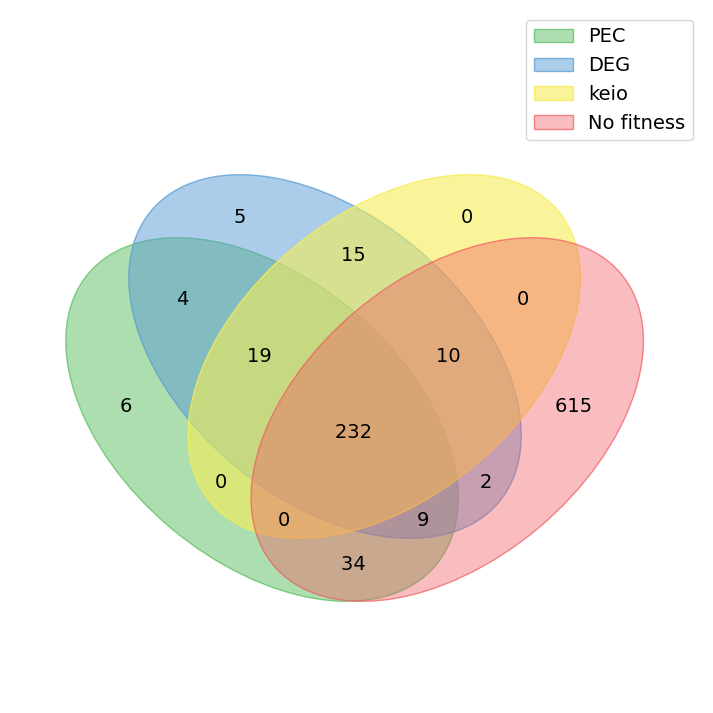

In [8]:
import matplotlib.pyplot as plt
from venn import venn4

labels = venn.get_labels([set_pec, set_deg, gkeio2, snofit], fill=['number'])
fig, ax = venn.venn4(labels, names=['PEC','DEG','keio', 'No fitness'])
fig.savefig('venn4.svg', format='svg')
for label in plt.gca().texts:
            label.set_fontsize(14) 

fig.show()

In [9]:
for key, conjunto in datas.items():
       
    otros_conjuntos = set.union(*(datas[k] for k in datas if k != key))
    unicos = conjunto - otros_conjuntos    
    print(f"Unicos de '{key}': {unicos}")
    print(len(unicos), '\n')
    
    if key == 'No fitness':
        No_fit = list(unicos)

Unicos de 'PEC': {'polA', 'kdsC', 'ftnA', 'priA', 'trpT', 'cysU'}
6 

Unicos de 'DEG': {'bcsB', 'ydfB', 'ydiL', 'tdcF', 'mlaB'}
5 

Unicos de 'keio': set()
0 

Unicos de 'No fitness': {'yliM', 'tusD', 'ynaN', 'rrfD', 'rrsE', 'ygdT', 'insH10', 'mdtU', 'yhiY', 'serU', 'yciB', 'cspA', 'rsxG', 'insF4', 'yjbL', 'aceF', 'ytgB', 'flgM', 'insD3', 'atpE', 'ybbC', 'yibV', 'holC', 'ytiD', 'b1364', 'insA1', 'yqhJ', 'ymfT', 'G6690', 'cspI', 'hemE', 'tufB', 'spf', 'ymiB', 'pheM', 'valV', 'aceK-int', 'yjgW', 'ymcF', 'valX', 'yfdF', 'insE1', 'lysV', 'ybfB', 'ydfA', 'lpxL', 'rpsF', 'ssrA', 'lysQ', 'kilR', 'tufA', 'G6294', 'yibX', 'yqeJ', 'ymiC', 'phoU', 'insL2', "3'ETS-<i>leuZ</i>", 'ptsH', 'pheU', 'insB3', 'sibB', 'valW', 'lysW', 'zwf', 'pheL', 'rrsB', 'insF3', 'yddY', 'ptsI', 'iroK', 'glyU', 'rhoL', 'metT', 'serW', 'yoeB', 'rpmI', 'nrdR', 'aspT', 'fimF', 'yldA', 'insL1', 'rrsH', 'b0725', 'yodC', 'ydcC', 'ileU', 'sibC', 'sroA', 'ydiE', 'rbfA', 'ygeF', 'atpA', 'agrA', 'cysB', 'sibD', 'msyB', 'yddM', 'h

In [10]:
print(len(snofit)) #902 No fit, que debo separar
print(len(No_fit))

essential_de_Nofit = list(set(snofit) - set(No_fit)) ##902-615= 287 se mueven a esenciales
print(len(essential_de_Nofit))   #287 genes en otras condiciones, en glucosa es dif
essen287_Otherconds = pd.DataFrame({ 'genes' : essential_de_Nofit})
essen287_Otherconds.to_csv('./essential_287gdeNofit_otherConds.csv', index=False)

noeff_de_Nofit = No_fit
noeff_de_Nofit = pd.DataFrame({ 'genes' : noeff_de_Nofit})
#noeff_de_Nofit.to_csv('./noeffect_615deNofit_otherConds.csv', index=False)

902
615
287


In [11]:
datas

{'PEC': {'accA',
  'accB',
  'accC',
  'accD',
  'acpP',
  'acpS',
  'adk',
  'alaS',
  'argS',
  'argU',
  'argX',
  'asd',
  'asnS',
  'aspS',
  'bamA',
  'bamD',
  'birA',
  'can',
  'cca',
  'cdsA',
  'coaA',
  'coaD',
  'coaE',
  'csrA',
  'cysS',
  'cysT',
  'cysU',
  'dapA',
  'dapB',
  'dapD',
  'dapE',
  'def',
  'degS',
  'der',
  'dfp',
  'dnaA',
  'dnaB',
  'dnaC',
  'dnaE',
  'dnaG',
  'dnaN',
  'dnaT',
  'dnaX',
  'dut',
  'dxr',
  'dxs',
  'efp',
  'eno',
  'era',
  'erpA',
  'fabA',
  'fabB',
  'fabD',
  'fabG',
  'fabI',
  'fabZ',
  'fbaA',
  'ffh',
  'ffs',
  'fldA',
  'fmt',
  'folA',
  'folB',
  'folC',
  'folD',
  'folE',
  'folK',
  'frr',
  'ftnA',
  'ftsA',
  'ftsB',
  'ftsE',
  'ftsH',
  'ftsI',
  'ftsK',
  'ftsL',
  'ftsN',
  'ftsQ',
  'ftsW',
  'ftsX',
  'ftsY',
  'ftsZ',
  'fusA',
  'gapA',
  'glmM',
  'glmS',
  'glmU',
  'glnS',
  'gltX',
  'glyQ',
  'glyS',
  'glyT',
  'gmk',
  'gpsA',
  'groL',
  'groS',
  'grpE',
  'gyrA',
  'gyrB',
  'hda',
  'hemA',
  

### In glucose condition

GL = 627


<AxesSubplot: >

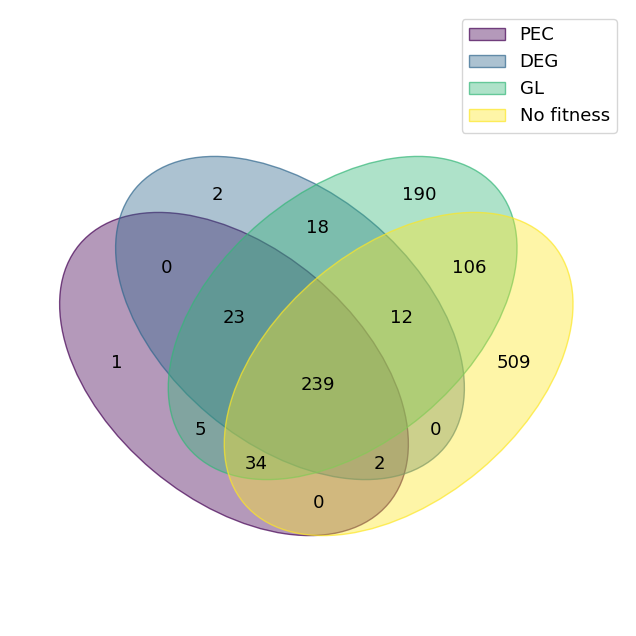

In [12]:
#Usando todos los genes
synom_GL = pd.read_csv('~/Notebooks/LIZ/Ntbooks_finales/synonym/GL_gen_synonym.csv')
type(synom_GL)
set_GL =set(synom_GL.Genes_R12)
print('GL =', len(set_GL))

from venn import *
#import venn.py
datas = {
    "PEC": set_pec,
    "DEG": set_deg,
    "GL" : set_GL,
    "No fitness" : snofit   
}
venn(datas)

Core GL = 494


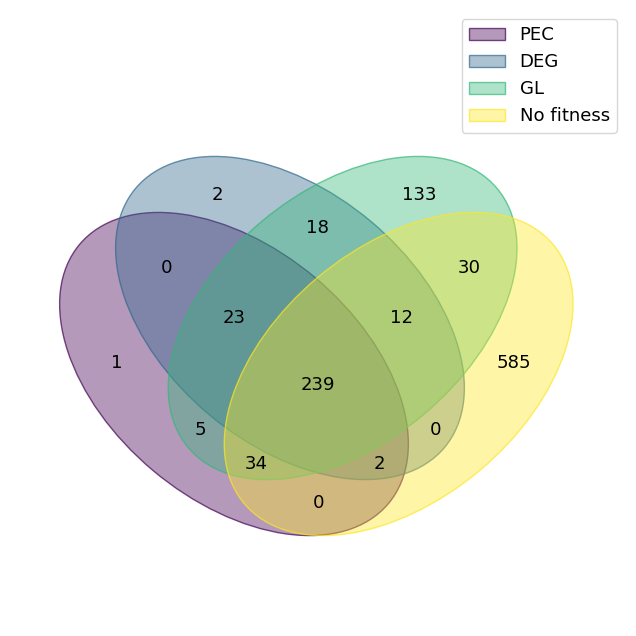

In [14]:
#Usando solo los genes core essential de Gustavo L 494 synon
Core_GL = pd.read_csv('~/Notebooks/LIZ/Ntbooks_finales/synonym/GL_core521_synonym.csv')
type(Core_GL)
Core_GL =set(Core_GL.Genes_R12)
print('Core GL =', len(Core_GL))

datas = {
    "PEC": set_pec,
    "DEG": set_deg,
    "GL" : Core_GL,
    "No fitness" : snofit   
}
venn(datas)
plt.savefig('venn_gnofitness_glucose.svg', format='svg')

In [15]:
for key, conjunto in datas.items():
       
    otros_conjuntos = set.union(*(datas[k] for k in datas if k != key))
    unicos_gluco = conjunto - otros_conjuntos    
    print(f"Unicos de '{key}': {unicos_gluco}")
    print(len(unicos_gluco), '\n')
    
    if key == 'No fitness':
        No_fit = list(unicos_gluco)

Unicos de 'PEC': {'ftnA'}
1 

Unicos de 'DEG': {'mlaB', 'ubiJ'}
2 

Unicos de 'GL': {'queF', 'rlmB', 'rluA', 'trpC', 'rlmA', 'leuC', 'argH', 'truA', 'aroA', 'mfd', 'cysI', 'rsmC', 'trpD', 'hisG', 'yafN', 'purE', 'dnaK', 'aroC', 'cysQ', 'rlmH', 'metF', 'thiI', 'mnmG', 'truC', 'truB', 'truD', 'cysN', 'lysA', 'rlmG', 'pyrF', 'queC', 'purF', 'sra', 'dnaJ', 'rluF', 'aroB', 'metA', 'rsuA', 'argB', 'hisI', 'pnp', 'hisC', 'cmoB', 'rlmN', 'rplI', 'purC', 'cysC', 'rlmI', 'rsmE', 'hisA', 'mnmE', 'trmA', 'pheA', 'rlmL', 'rlmD', 'purL', 'thrC', 'miaB', 'argA', 'queG', 'rluE', 'rpoS', 'tyrA', 'trpE', 'rlmM', 'queA', 'ilvE', 'yfiC', 'trmH', 'purA', 'rlmC', 'argD', 'pdxB', 'purH', 'miaA', 'ttcA', 'trpA', 'rpmG', 'rsmB', 'pyrE', 'tmcA', 'hisD', 'trpB', 'thiH', 'mnmC', 'thrB', 'hisH', 'dusA', 'queD', 'pdxA', 'trmJ', 'gltA', 'trmB', 'purK', 'leuB', 'cysH', 'ilvC', 'rhlB', 'greB', 'argG', 'ilvD', 'pyrB', 'rsmA', 'purD', 'rluC', 'rpoZ', 'leuA', 'rsmD', 'purM', 'glgA', 'serC', 'leuD', 'hisB', 'rlmF', 'rluB'

## Create a list of the genes that moved from non-fitness to essential.

In [16]:
snofit = set(genes_nofit.genes)  #902 No fit, que debo separar
print(len(snofit),'\n')
print(len(No_fit))

essential_de_Nofit = list((snofit) - set(No_fit))   ##902-585= 317 se mueven a esenciales
print(len(essential_de_Nofit)) #317
essen317_deNofit = pd.DataFrame({ 'genes' : essential_de_Nofit})
#essen317_deNofit.to_csv('./essential_317Nofit_glucose.csv')

902 

585
317
